# 🧠 Week 11 실습 — 뉴럴 네트워크 기초

**머신러닝 기초 및 실습 (학부) · Spring 2026**

이론 강의에서 배운 **신경망(Neural Network)** 개념을
직접 코드로 실행해보면서 눈으로 확인! 🎯

### 실습 내용의 구성 (약 30분 소요 예상)
| 파트 | 무엇을 해볼까요? | 강의 개념 |
|---|---|---|
| 1 | 뉴런 1개 만들기 (가중합) | 퍼셉트론, 가중합 |
| 2 | 활성화 함수 그려보기 | ReLU · Sigmoid · tanh |
| 3 | 신경망 구조 보기 + 분류 실험 | 다층 퍼셉트론 |
| 4 | "선형만 쌓으면 직선" 실험 | 비선형성의 필요성 |
| 5 | 손글씨 숫자 알아맞히기 | Softmax · 다층 퍼셉트론 |

- 코드를 외울 필요는 **전혀 없습니다.** 실행 결과 및 그림 등을 보고 "아 이렇구나!" 하고 이해할 수 있으면 충분해요.
- 셀을 실행하면 나오는 **그림과 숫자**를 천천히 살펴보세요. 🔍

> 💡 코드 한 줄 한 줄을 다 이해 못 해도 괜찮습니다. **그림과 숫자의 변화**에 집중하세요!


## 0️⃣ 필요한 라이브러리 불러오기

아래 셀을 실행하면 실습에 필요한 라이브러리들을 import: `numpy`(숫자 계산), `matplotlib`(그림 그리기), `scikit-learn`(머신러닝)을 사용


In [4]:
from IPython.display import Image
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits, make_moons
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')           # 자잘한 경고 메시지 숨기기

plt.rcParams['axes.unicode_minus'] = False  # 그래프에서 마이너스 기호 깨짐 방지
plt.rcParams['figure.figsize'] = (7, 4)

## 1️⃣ 뉴런 1개 = 가중합 (Weighted Sum)

강의에서 배운 **퍼셉트론(뉴런)** 의 핵심은 딱 한 문장이었습니다:

$$ y = x_1 w_1 + x_2 w_2 + x_3 w_3 + b $$

> **입력값마다 "중요도(가중치 w)"를 곱해서 모두 더하고, 편향 b를 더한다.**

강의 슬라이드의 예시를 코드로 구현 🎬
**"Youtube · TV · 신문 광고비"** 를 입력하면 **"제품 판매량"** 을 예측하는 뉴런

In [2]:
# 입력 x : 광고비 (강의 슬라이드의 첫 번째 데이터와 동일)
youtube, tv, newspaper = 130, 70, 55
x = np.array([youtube, tv, newspaper])

# 가중치 w : 각 광고 채널이 판매량에 주는 '영향력' (일단 임의로 추측한 값을 넣어 실행)
w = np.array([1.0, 0.8, 0.3])

# 편향 b : 광고가 0이어도 기본적으로 팔리는 양
b = 7.0

# 뉴런의 계산: 가중합
y = np.dot(x, w) + b   # = x1*w1 + x2*w2 + x3*w3 + b

print(f"Youtube {youtube}  ×  w={w[0]}  →  {youtube*w[0]:.1f}")
print(f"TV      {tv}  ×  w={w[1]}  →  {tv*w[1]:.1f}")
print(f"신문     {newspaper}  ×  w={w[2]}  →  {newspaper*w[2]:.1f}")
print(f"편향(bias)               →  {b:.1f}")
print("-" * 35)
print(f"📈 예측 판매량 y = {y:.1f}")
print("(슬라이드의 실제 판매량은 221 이었어요. 가중치를 잘 '학습'하면 더 정확해집니다!)")


Youtube 130  ×  w=1.0  →  130.0
TV      70  ×  w=0.8  →  56.0
신문     55  ×  w=0.3  →  16.5
편향(bias)               →  7.0
-----------------------------------
📈 예측 판매량 y = 209.5
(슬라이드의 실제 판매량은 221 이었어요. 가중치를 잘 '학습'하면 더 정확해집니다!)


### 🔍 뉴런을 그림으로 보기

방금 계산을 강의 슬라이드처럼 **그림(네트워크)** 으로 시각화

입력들이 화살표(가중치 w)를 타고 가운데 ∑ 로 모이고, **편향(bias) 노드(보라색)** 도 함께 더해져서 출력 y 가 나오는 구조

<img src='https://raw.githubusercontent.com/agtechresearch/LectureMLbasic/main/img/W11_nn_ad.png' align="left" width="700">


## 2️⃣ 활성화 함수 (Activation Function)

가중합만으로는 **직선(선형)** 밖에 표현하지 못합니다.
그래서 뉴런은 가중합 결과를 **활성화 함수** 에 통과시킵니다.

강의에서 언급한 대표적인 활성화 함수 3가지. 🖍️

- **ReLU** : 음수는 0, 양수는 그대로 (가장 많이 씀)
- **Sigmoid** : 어떤 값이든 0~1 사이로 (확률처럼)
- **tanh** : 어떤 값이든 -1~1 사이로

<img src='https://raw.githubusercontent.com/agtechresearch/LectureMLbasic/main/img/W11_activation_function.png' align="left">

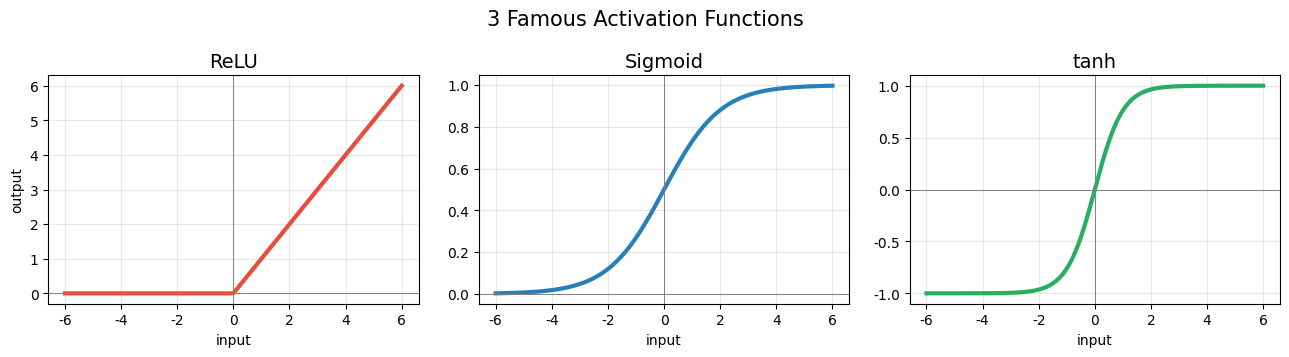

In [ ]:
# 대표적인 활성화 함수 3가지 그림으로 그려보기
z = np.linspace(-6, 6, 300)

relu    = np.maximum(0, z)
sigmoid = 1 / (1 + np.exp(-z))
tanh    = np.tanh(z)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.6))
for ax, name, vals, color in zip(
        axes, ['ReLU', 'Sigmoid', 'tanh'],
        [relu, sigmoid, tanh], ['#E74C3C', '#2980B9', '#27AE60']):
    ax.plot(z, vals, color=color, lw=3)
    ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
    ax.set_title(name, fontsize=14); ax.set_xlabel("input")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("output")
plt.suptitle("3 Famous Activation Functions", fontsize=15)
plt.tight_layout()
plt.show()


### 🔍 입력값을 넣으면 어떤 값이 나올까?

같은 입력값 몇 개(**-4, -1, 0, 1, 4**)를 세 함수에 똑같이 넣어보면,
**함수마다 전혀 다른 출력** 으로 바뀜


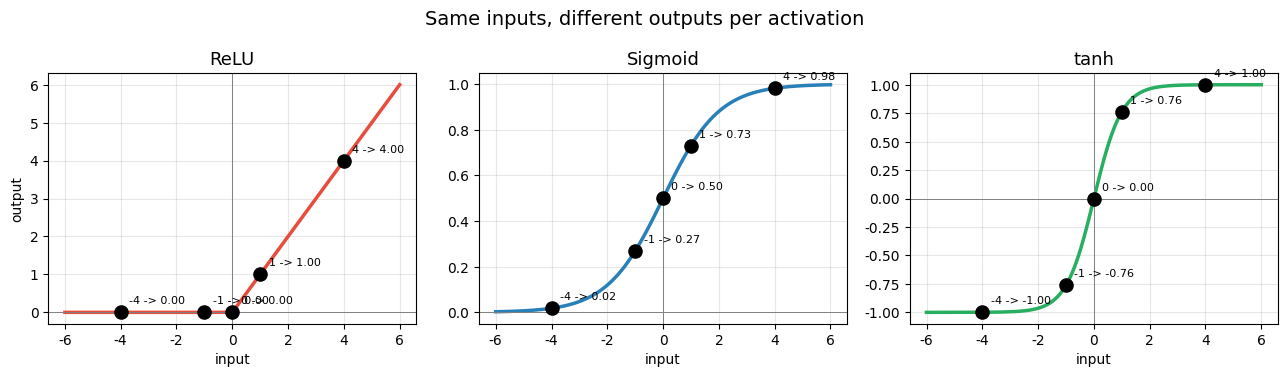

input  -4  ->  ReLU 0.00    Sigmoid 0.02    tanh -1.00
input  -1  ->  ReLU 0.00    Sigmoid 0.27    tanh -0.76
input   0  ->  ReLU 0.00    Sigmoid 0.50    tanh 0.00
input   1  ->  ReLU 1.00    Sigmoid 0.73    tanh 0.76
input   4  ->  ReLU 4.00    Sigmoid 0.98    tanh 1.00


In [ ]:
# 같은 입력값 몇 개를 세 함수에 똑같이 통과시켜 비교
sample_inputs = [-4, -1, 0, 1, 4]
funcs = {'ReLU':    lambda v: max(0.0, v),
         'Sigmoid': lambda v: 1.0 / (1.0 + np.exp(-v)),
         'tanh':    lambda v: np.tanh(v)}

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
for ax, name, vals, color in zip(
        axes, ['ReLU', 'Sigmoid', 'tanh'],
        [relu, sigmoid, tanh], ['#E74C3C', '#2980B9', '#27AE60']):
    ax.plot(z, vals, color=color, lw=2.5)
    ax.axhline(0, color='gray', lw=0.7); ax.axvline(0, color='gray', lw=0.7)
    for v in sample_inputs:
        o = funcs[name](v)
        ax.scatter([v], [o], s=90, c='black', zorder=5)
        ax.annotate(f"{v} -> {o:.2f}", (v, o), textcoords="offset points",
                    xytext=(6, 6), fontsize=8)
    ax.set_title(name, fontsize=13); ax.grid(alpha=0.3); ax.set_xlabel("input")
axes[0].set_ylabel("output")
plt.suptitle("Same inputs, different outputs per activation", fontsize=14)
plt.tight_layout(); plt.show()

for v in sample_inputs:
    print(f"input {v:>3}  ->  ReLU {max(0.0, v):.2f}    "
          f"Sigmoid {1.0/(1.0+np.exp(-v)):.2f}    tanh {np.tanh(v):.2f}")


## 3️⃣ 뉴럴 네트워크의 구조 보기 + 간단한 분류 실험 🕸️

지금까지 뉴런을 **1개** 만 살펴보았습니다. 이 뉴런을 **여러 개·여러 층** 으로 쌓으면 강의에서 배운 **다층 퍼셉트론(Multi-Layer Perceptron)** 이 됩니다.

먼저 입력층 → 은닉층 → 출력층 구조를 그림으로 봅시다.

In [6]:
# 네트워크를 시각화 해주기 위한 함수 - 아래 함수는 이해하지 않아도 됩니다.
def draw_network(layer_sizes, title="Neural Network Structure"):
    fig, ax = plt.subplots(figsize=(8.5, 5))
    ax.axis('off')
    L = len(layer_sizes)
    xs = np.linspace(0.07, 0.93, L)
    colors = ['#7FB3D5'] + ['#F5B041'] * (L - 2) + ['#82E0AA']
    pos = []
    for x, m in zip(xs, layer_sizes):
        yy = np.linspace(0.82, 0.18, m) if m > 1 else np.array([0.5])
        pos.append([(x, v) for v in yy])
    # 층과 층 사이를 모두 연결 (fully connected)
    for li in range(L - 1):
        for (x1, y1) in pos[li]:
            for (x2, y2) in pos[li + 1]:
                ax.plot([x1, x2], [y1, y2], color='lightgray', lw=0.6, zorder=1)
    names = ['Input'] + [f'Hidden{i+1}' for i in range(L - 2)] + ['Output']
    for li, layer in enumerate(pos):
        for (x, v) in layer:
            ax.scatter(x, v, s=850, c=colors[li], zorder=3, edgecolors='white')
        ax.text(xs[li], 0.95, f"{names[li]}\n({layer_sizes[li]})",
                ha='center', va='center', fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0.05, 1.02)
    ax.set_title(title, fontsize=13)
    plt.show()

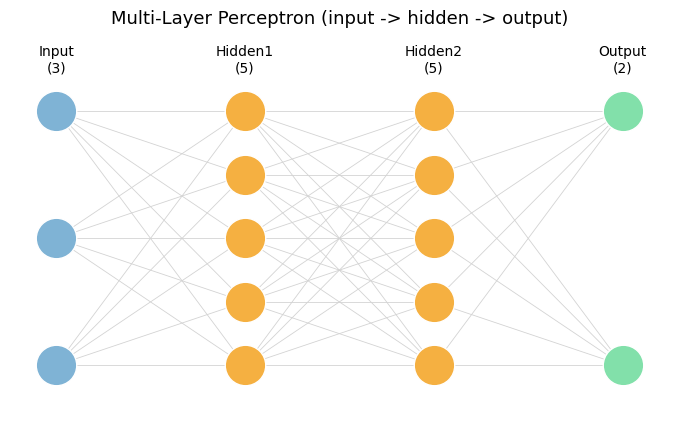

In [7]:
# 입력 3개 -> 은닉층(5) -> 은닉층(5) -> 출력 2개 짜리 다층 퍼셉트론
draw_network([3, 5, 5, 2], title="Multi-Layer Perceptron (input -> hidden -> output)")


### 🌙 간단한 분류 문제 — 두 개의 반달 나누기

직선 하나로는 절대 못 나누는 **두 개의 반달(two moons)** 데이터를
작은 뉴럴넷을 통해 분류 시도

결과 그림에서 **색칠된 영역** 은 뉴럴넷 분류 결과


In [8]:
# '두 개의 반달' 모양 데이터 만들기 (직선 하나로는 못 나눔)
Xm, ym = make_moons(n_samples=300, noise=0.20, random_state=0)

# 작은 뉴럴넷(은닉층 2개)으로 분류 학습
net = MLPClassifier(hidden_layer_sizes=(16, 16), activation='relu',
                    max_iter=2000, random_state=0).fit(Xm, ym)
acc = net.score(Xm, ym)

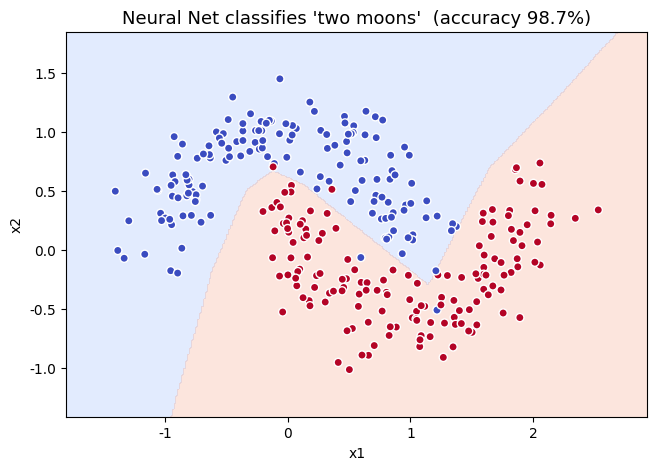

🎯 정확도: 98.7%
직선으로는 못 나누는 두 반달을, 뉴럴넷 '곡선 경계'로 깔끔히 분리!


In [9]:
# 뉴럴넷 결과 시각화
gx, gy = np.meshgrid(
    np.linspace(Xm[:, 0].min() - 0.4, Xm[:, 0].max() + 0.4, 300),
    np.linspace(Xm[:, 1].min() - 0.4, Xm[:, 1].max() + 0.4, 300))
zz = net.predict(np.c_[gx.ravel(), gy.ravel()]).reshape(gx.shape)

plt.figure(figsize=(7.5, 5))
plt.contourf(gx, gy, zz, alpha=0.25, cmap='coolwarm', levels=1)
plt.scatter(Xm[:, 0], Xm[:, 1], c=ym, cmap='coolwarm',
            edgecolors='white', s=35)
plt.title(f"Neural Net classifies 'two moons'  (accuracy {acc*100:.1f}%)",
          fontsize=13)
plt.xlabel("x1"); plt.ylabel("x2")
plt.show()

print(f"🎯 정확도: {acc*100:.1f}%")
print("직선으로는 못 나누는 두 반달을, 뉴럴넷 '곡선 경계'로 깔끔히 분리!")

## 4️⃣ 활성화 함수가 왜 꼭 필요할까? 🤔

방금 뉴럴넷이 두 반달을 **곡선** 으로 깔끔하게 분류하였습니다.
그 곡선이 가능했던 비밀이 바로 **비선형 활성화 함수** 입니다.

이론 강의에서의 핵심 메시지:

> **"선형 변환을 아무리 여러 번 쌓아도 결국 하나의 직선(선형)일 뿐이다."**
>
> 비선형 활성화 함수가 들어가야 비로소 **곡선/복잡한 모양** 을 표현할 수 있다!

직접 코딩을 통한 실습/실험

구불구불한 데이터(사인 곡선)를 **① 선형만 쓰는 신경망** 과 **② ReLU를 쓰는 신경망** 으로 각각 학습시켜 비교


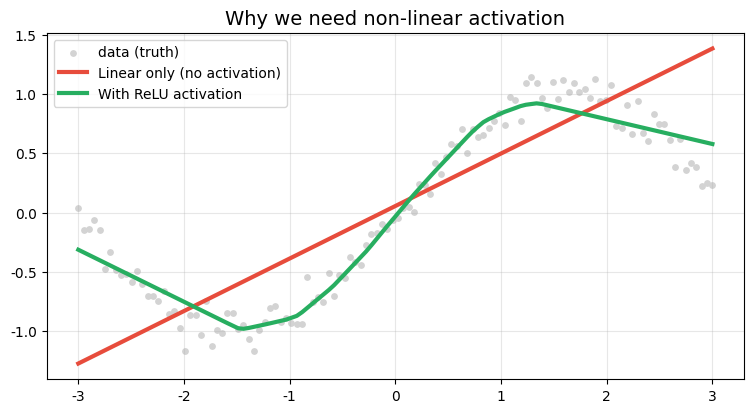

👀 빨간선(선형만): 층을 30개씩 쌓아도 결국 '직선' → 곡선을 못 따라감
✅ 초록선(ReLU)  : 구불구불한 곡선을 잘 따라감 → 비선형성의 힘!


In [ ]:
rng = np.random.RandomState(0)
X = np.linspace(-3, 3, 120).reshape(-1, 1)
y_true = np.sin(X).ravel() + 0.10 * rng.randn(120)   # 구불구불 + 약간의 잡음

# ① 활성화 함수 없음(선형 only) — activation='identity'
net_linear = MLPRegressor(hidden_layer_sizes=(30, 30), activation='identity',
                          max_iter=3000, random_state=0).fit(X, y_true)
# ② ReLU 활성화 함수 사용
net_relu   = MLPRegressor(hidden_layer_sizes=(30, 30), activation='relu',
                          max_iter=3000, random_state=0).fit(X, y_true)

# 결과에 대한 시각화
plt.figure(figsize=(9, 4.5))
plt.scatter(X, y_true, s=15, c='lightgray', label='data (truth)')
plt.plot(X, net_linear.predict(X), c='#E74C3C', lw=3, label='Linear only (no activation)')
plt.plot(X, net_relu.predict(X),   c='#27AE60', lw=3, label='With ReLU activation')
plt.title("Why we need non-linear activation", fontsize=14)
plt.legend(); plt.grid(alpha=0.3)
plt.show()

print("👀 빨간선(선형만): 층을 30개씩 쌓아도 결국 '직선' → 곡선을 못 따라감")
print("✅ 초록선(ReLU)  : 구불구불한 곡선을 잘 따라감 → 비선형성의 힘!")


## 5️⃣ 손글씨 숫자 알아맞히기 ✍️

**"손글씨 숫자"** 알아맞히기

픽셀 → 입력 노드 → 은닉층 → Softmax → "어떤 숫자일 확률".

이번엔 진짜 손글씨 숫자 데이터(8×8 픽셀 이미지 1,797장)로 **다층 퍼셉트론(MLP)** 을 학습시켜 봅니다.


이미지 개수 : 1797 장
이미지 크기 : 8 x 8 픽셀
정답 종류   : [0 1 2 3 4 5 6 7 8 9]  (0~9)


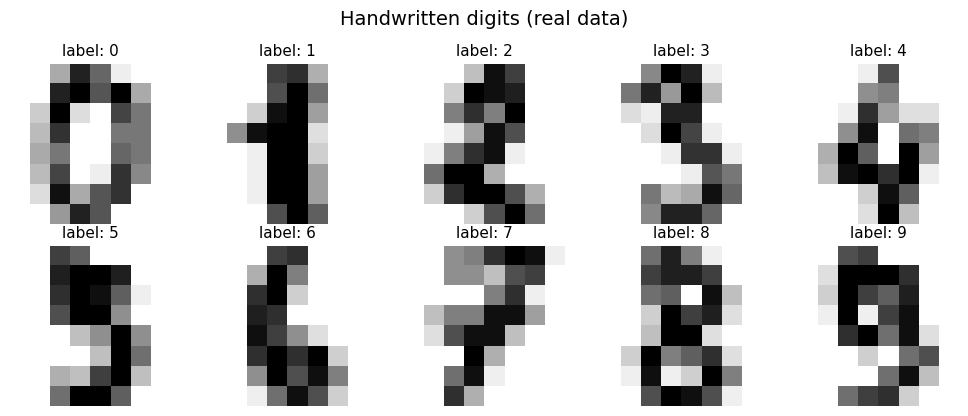

In [10]:
# scikit-learn 에서 기본적으로 제공하는 순글씨 숫자 데이터셋 가져오기
digits = load_digits()

print(f"이미지 개수 : {digits.images.shape[0]} 장")
print(f"이미지 크기 : {digits.images.shape[1]} x {digits.images.shape[2]} 픽셀")
print(f"정답 종류   : {np.unique(digits.target)}  (0~9)")

# 샘플 10장 구경하기
fig, axes = plt.subplots(2, 5, figsize=(10, 4.2))
for ax, img, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f"label: {label}", fontsize=11)
    ax.axis('off')
plt.suptitle("Handwritten digits (real data)", fontsize=14)
plt.tight_layout(); plt.show()


### 🔢 컴퓨터는 이미지를 '숫자'로 봅니다

강의 슬라이드의 `P1=0, P7=255 ...` 처럼,
컴퓨터에게 이미지는 그냥 **숫자가 가득한 표** 입니다.

첫 번째 이미지를 숫자로 들여다본다면?


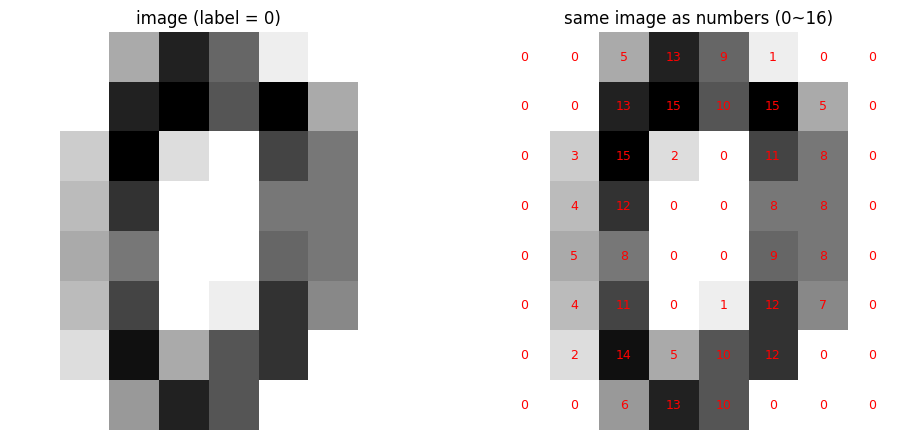

이 8x8 = 64개의 숫자가 바로 신경망의 '입력(input node)' 64개가 됩니다.


In [11]:
one = digits.images[0]
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
axes[0].imshow(one, cmap='gray_r'); axes[0].set_title(f"image (label = {digits.target[0]})")
axes[0].axis('off')
axes[1].imshow(one, cmap='gray_r')
for i in range(8):
    for j in range(8):
        axes[1].text(j, i, int(one[i, j]), ha='center', va='center',
                     color='red', fontsize=9)
axes[1].set_title("same image as numbers (0~16)")
axes[1].axis('off')
plt.tight_layout(); plt.show()
print("이 8x8 = 64개의 숫자가 바로 신경망의 '입력(input node)' 64개가 됩니다.")


### 🏋️ 신경망 학습시키기

이미지 64개 픽셀 → **은닉층(뉴런 64개)** → **출력 10개(0~9) + Softmax**.
데이터를 학습용/시험용으로 나눠서, 학습용으로만 공부시키고
**한 번도 본 적 없는 시험용** 이미지로 실력을 평가!


In [12]:
X = digits.data / 16.0          # 0~16 → 0~1 로 정규화/스케일 (학습이 잘 됨)
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42)

clf = MLPClassifier(hidden_layer_sizes=(64,), activation='relu',
                     max_iter=400, random_state=1)
clf.fit(X_train, y_train)

acc = clf.score(X_test, y_test)
print(f"📚 학습용 이미지 : {len(X_train)} 장")
print(f"📝 시험용 이미지 : {len(X_test)} 장")
print(f"🎯 시험 정확도   : {acc*100:.1f}%   (처음 보는 손글씨를 이만큼 맞혔어요!)")


📚 학습용 이미지 : 1347 장
📝 시험용 이미지 : 450 장
🎯 시험 정확도   : 97.6%   (처음 보는 손글씨를 이만큼 맞혔어요!)


### 🖼️ 신경망의 채점 결과 보기

시험용 이미지 15장에 대한 예측입니다.
**초록색 = 정답**, **빨간색 = 오답**.


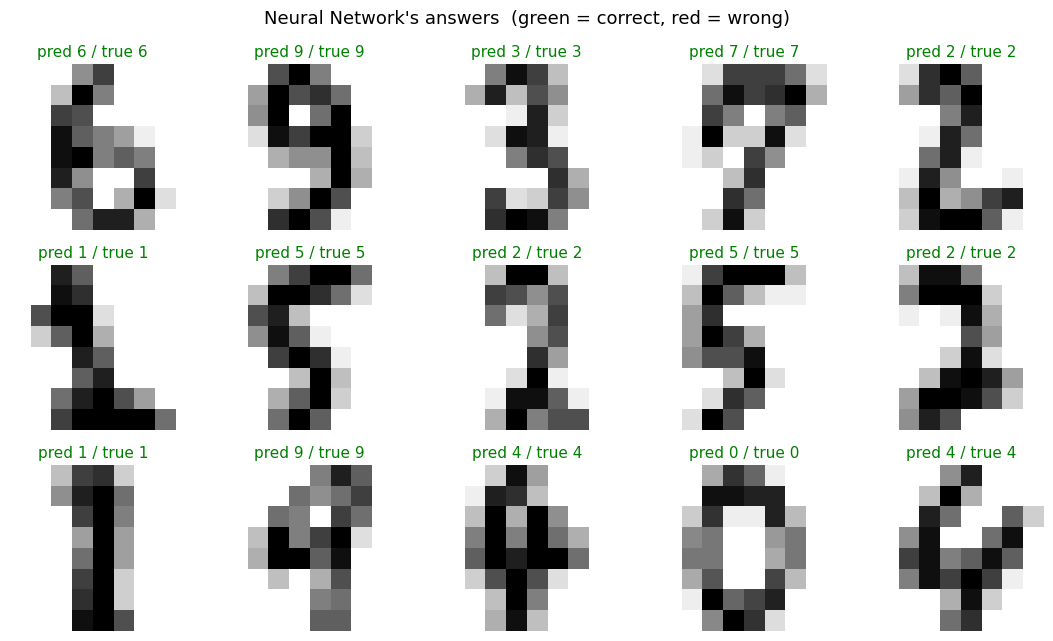

In [13]:
pred = clf.predict(X_test)

fig, axes = plt.subplots(3, 5, figsize=(11, 6.5))

for ax, idx in zip(axes.ravel(), range(15)):
    img = X_test[idx].reshape(8, 8)
    ok = (pred[idx] == y_test[idx])
    ax.imshow(img, cmap='gray_r')
    ax.set_title(f"pred {pred[idx]} / true {y_test[idx]}",
                 color=('green' if ok else 'red'), fontsize=11)
    ax.axis('off')

plt.suptitle("Neural Network's answers  (green = correct, red = wrong)", fontsize=13)
plt.tight_layout(); plt.show()


### 📊 Softmax — "몇 % 확률로 이 숫자일까?"

강의 슬라이드에서 언급한 출력층의 **Softmax** 는 10개 숫자에 대한 **확률(합 = 1)** 을 알려줍니다.
시험 이미지 몇 장에 대해 신경망의 '확신도'를 막대그래프로 봅니다.


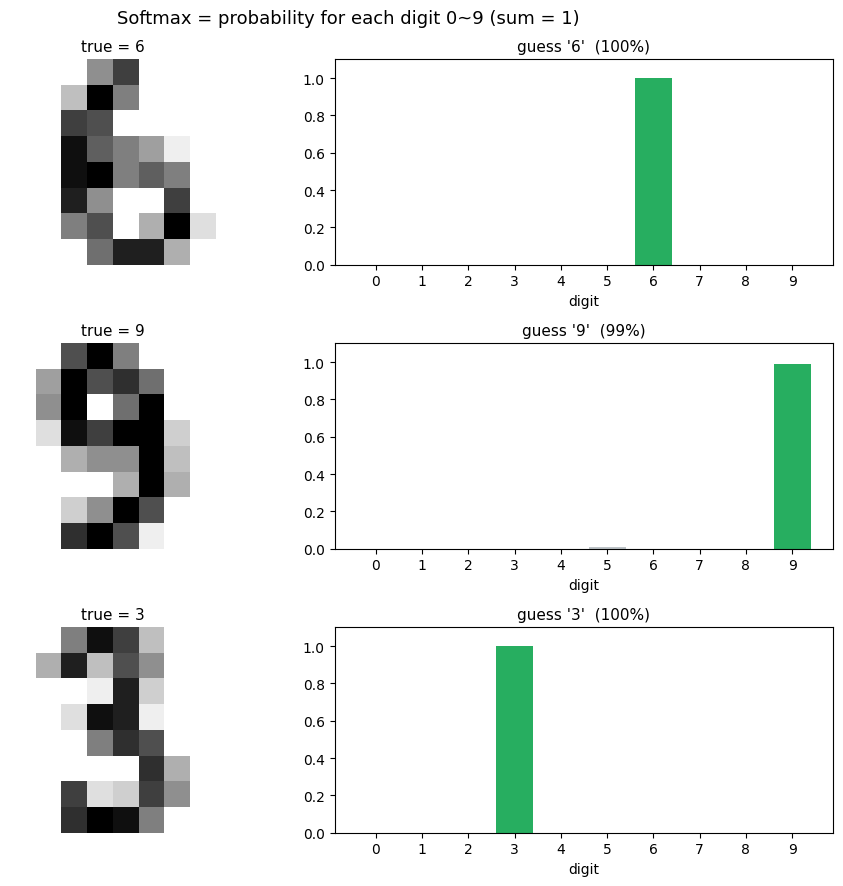

In [15]:
def draw_one(ax_img, ax_bar, idx):
    img = X_test[idx].reshape(8, 8)
    proba = clf.predict_proba([X_test[idx]])[0]
    guess = proba.argmax()
    ax_img.imshow(img, cmap='gray_r')
    ax_img.set_title(f"true = {y_test[idx]}", fontsize=11)
    ax_img.axis('off')
    colors = ['#27AE60' if k == guess else '#BDC3C7' for k in range(10)]
    ax_bar.bar(range(10), proba, color=colors)
    ax_bar.set_xticks(range(10))
    ax_bar.set_ylim(0, 1.1)
    ax_bar.set_xlabel("digit")
    ax_bar.set_title(f"guess '{guess}'  ({proba[guess]*100:.0f}%)", fontsize=11)

# 시험 이미지 3장에 대한 Softmax 확률을 한 번에 보여줌
examples = [0, 1, 2]
fig, axes = plt.subplots(len(examples), 2, figsize=(10, 3.0 * len(examples)))
for row, idx in enumerate(examples):
    draw_one(axes[row, 0], axes[row, 1], idx)
plt.suptitle("Softmax = probability for each digit 0~9 (sum = 1)", fontsize=13)
plt.tight_layout()
plt.show()


### 🕵️ 신경망이 틀린 문제만 모아보기

사람도 헷갈리는 글씨가 있죠. 신경망이 **틀린 것들** 만 모아봤어요.
"이건 사람도 헷갈리겠다!" 싶은 게 보이나요?


전체 450장 중 11장 틀림


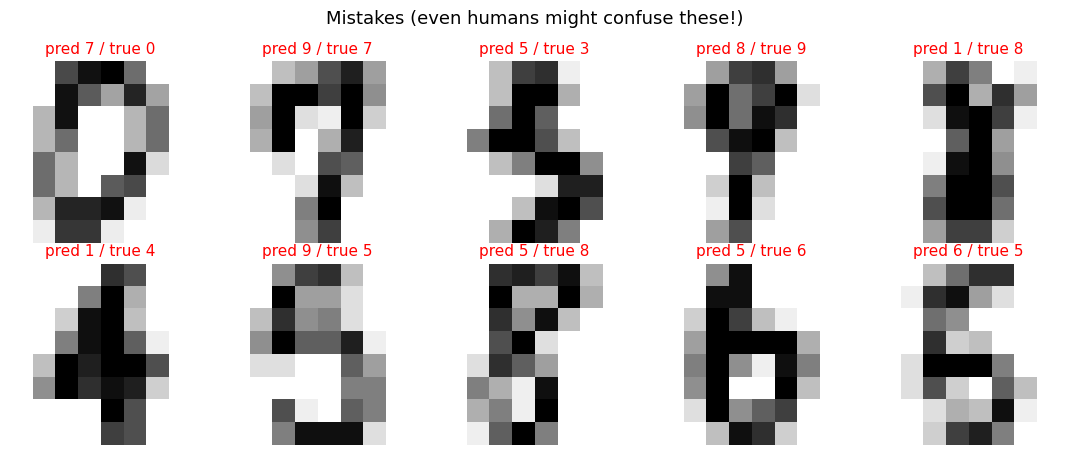

In [16]:
wrong = np.where(pred != y_test)[0]
print(f"전체 {len(y_test)}장 중 {len(wrong)}장 틀림")

n = min(10, len(wrong))
if n > 0:
    fig, axes = plt.subplots(2, 5, figsize=(11, 4.6))
    for ax in axes.ravel():
        ax.axis('off')
    for ax, idx in zip(axes.ravel(), wrong[:n]):
        ax.imshow(X_test[idx].reshape(8, 8), cmap='gray_r')
        ax.set_title(f"pred {pred[idx]} / true {y_test[idx]}",
                     color='red', fontsize=11)
    plt.suptitle("Mistakes (even humans might confuse these!)", fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print("와! 하나도 안 틀렸어요 🎉")


## 🎓 정리 — 오늘 우리가 한 것

| 실습 | 확인한 강의 개념 |
|---|---|
| 1️⃣ 광고 → 판매량 뉴런 | 뉴런 = **가중합 $\sum x_i w_i + b$** |
| 2️⃣ ReLU/Sigmoid/tanh | **활성화 함수** = 비선형 변환 |
| 3️⃣ 신경망 구조 + 두 반달 분류 | **다층 퍼셉트론** 으로 곡선 분류 |
| 4️⃣ 선형 vs ReLU 곡선 | 비선형이 없으면 **결국 직선** |
| 5️⃣ 손글씨 인식 | 입력 → 은닉층 → **Softmax 확률** |

**핵심 한 줄:** 신경망 = `가중합` + `비선형 활성화` 를 여러 층 쌓은 것.
층을 쌓고 가중치를 학습하면, 직선으로 못 풀던 문제도 풀 수 있다! 🚀

### 🧪 더 해보고 싶다면? (도전 과제)
1. **6️⃣** 의 `hidden_layer_sizes=(64,)` 를 `(16,)` 이나 `(128, 64)` 로 바꿔 정확도 비교해보기
2. **6️⃣** 의 `max_iter=400` 을 `50` 으로 줄이면 정확도가 어떻게 될까?
3. **5️⃣** 에서 `y = np.array([0, 1, 1, 0])` 을 `AND`(`[0,0,0,1]`)로 바꾸면 단층도 풀 수 있을까?
4. **3️⃣** 의 `make_moons(noise=0.20)` 에서 noise를 `0.05` 나 `0.40` 으로 바꿔 경계 변화 관찰
5. 강의에서 본 시각화 놀이터도 직접 체험해보기 👉 https://playground.tensorflow.org/

### 다음 실습 예고
다음 실습에서는 **트랜스포머(Transformer)** 기초를 배우고 실습합니다. 수고하셨습니다! 👏
